## Leakage Analysis — Statistical Discovery of Metadata Artifacts

**Goal**: Instead of hardcoding cleaning rules (e.g. removing "(Reuters)"), use statistics to discover which tokens are dataset artifacts vs. genuine content signals.

**Approach**:
1. Load raw (uncleaned) text
2. Compute per-class token frequencies and frequency ratios
3. Use chi-squared and mutual information to rank tokens by label association
4. Distinguish metadata artifacts (remove) from content signals (keep)
5. Use findings to justify the cleaning pipeline

In [6]:
import kagglehub
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_selection import chi2, mutual_info_classif
import matplotlib.pyplot as plt
import seaborn as sns

### Load raw data (before any cleaning)

In [7]:
path = kagglehub.dataset_download("clmentbisaillon/fake-and-real-news-dataset")

true_df = pd.read_csv(f"{path}/True.csv")
fake_df = pd.read_csv(f"{path}/Fake.csv")

true_df["label"] = 1
fake_df["label"] = 0

true_df.drop(columns=["title", "subject", "date"], inplace=True)
fake_df.drop(columns=["title", "subject", "date"], inplace=True)

raw_df = pd.concat([true_df, fake_df], ignore_index=True).drop_duplicates()
raw_df.shape

(38647, 2)

### Step 1: Token frequency ratio between classes

For each token, compute how often it appears in real vs. fake articles. Extreme ratios flag potential leakage.

In [8]:
vectorizer = CountVectorizer(max_features=20_000, stop_words="english")
X = vectorizer.fit_transform(raw_df["text"])
y = raw_df["label"].values
feature_names = np.array(vectorizer.get_feature_names_out())

real_mask = y == 1
fake_mask = y == 0

freq_real = np.asarray(X[real_mask].sum(axis=0)).flatten()
freq_fake = np.asarray(X[fake_mask].sum(axis=0)).flatten()

# Add smoothing to avoid division by zero
smoothing = 1
ratio_real_over_fake = (freq_real + smoothing) / (freq_fake + smoothing)
ratio_fake_over_real = (freq_fake + smoothing) / (freq_real + smoothing)

freq_df = pd.DataFrame({
    "token": feature_names,
    "freq_real": freq_real,
    "freq_fake": freq_fake,
    "ratio_real_fake": ratio_real_over_fake,
    "ratio_fake_real": ratio_fake_over_real,
})

print("=== Tokens most skewed toward REAL (potential metadata from real sources) ===")
freq_df.sort_values("ratio_real_fake", ascending=False).head(20)

=== Tokens most skewed toward REAL (potential metadata from real sources) ===


,token,freq_real,freq_fake,ratio_real_fake,ratio_fake_real
15484,rohingya,2036,1,1018.500000,0.000982
14454,rakhine,888,0,889.000000,0.001125
19998,zuma,646,0,647.000000,0.001546
14224,puigdemont,641,0,642.000000,0.001558
12001,myanmar,2813,4,562.800000,0.001777
7007,fdp,516,0,517.000000,0.001934
17646,suu,489,0,490.000000,0.002041
10277,kyi,488,0,489.000000,0.002045
11713,mnangagwa,395,0,396.000000,0.002525
14453,rajoy,386,0,387.000000,0.002584


In [9]:
print("=== Tokens most skewed toward FAKE (potential metadata from fake sources) ===")
freq_df.sort_values("ratio_fake_real", ascending=False).head(20)

=== Tokens most skewed toward FAKE (potential metadata from fake sources) ===


,token,freq_real,freq_fake,ratio_real_fake,ratio_fake_real
8851,https,0,3508,0.000285,3509.00
7834,getty,1,4138,0.000483,2069.50
13372,pic,3,4986,0.000802,1246.75
316,21wire,0,1077,0.000928,1078.00
14377,quot,0,1000,0.000999,1001.00
9957,js,0,887,0.001126,888.00
7283,flickr,0,585,0.001706,586.00
16781,somodevilla,0,466,0.002141,467.00
271,2017the,0,462,0.002160,463.00
7233,fjs,0,441,0.002262,442.00


### Step 2: Chi-squared test

Measures whether a token's presence is statistically independent of the label. High score = strong association with one class.

In [15]:
chi2_scores, chi2_pvalues = chi2(X, y)

chi2_df = pd.DataFrame({
    "token": feature_names,
    "chi2_score": chi2_scores,
    "p_value": chi2_pvalues,
    "freq_real": freq_real,
    "freq_fake": freq_fake,
    "ratio_real_fake": ratio_real_over_fake,
    "ratio_fake_real": ratio_fake_over_real
}).sort_values("chi2_score", ascending=False)

print("=== Top 30 tokens by chi-squared score (strongest label association) ===")
chi2_df.head(30)

=== Top 30 tokens by chi-squared score (strongest label association) ===


,token,chi2_score,p_value,freq_real,freq_fake,ratio_real_fake,ratio_fake_real
15695,said,30788.275171,0.0,97814,24803,3.943517,0.253581
15262,reuters,22762.216136,0.0,28652,301,94.877483,0.010540
9039,image,10403.491133,0.0,362,9483,0.038275,26.126722
10010,just,9864.691518,0.0,4410,16742,0.263453,3.795738
7021,featured,9564.997487,0.0,100,8139,0.012408,80.594059
3803,com,7228.544087,0.0,208,6483,0.032233,31.023923
10646,like,7103.268220,0.0,4634,14358,0.322794,3.097950
13372,pic,6043.834611,0.0,3,4986,0.000802,1246.750000
8647,hillary,5677.207591,0.0,2728,9945,0.274382,3.644558
18617,twitter,5578.946516,0.0,2492,9465,0.263364,3.797032


### Step 3: Mutual Information

Measures how much knowing a token's presence reduces uncertainty about the label (in bits). Complementary to chi-squared — captures non-linear associations.

In [11]:
mi_scores = mutual_info_classif(X, y, discrete_features=True, random_state=42)

mi_df = pd.DataFrame({
    "token": feature_names,
    "mi_score": mi_scores,
    "freq_real": freq_real,
    "freq_fake": freq_fake,
    "ratio_real_fake": ratio_real_over_fake,
}).sort_values("mi_score", ascending=False)

print("=== Top 30 tokens by mutual information ===")
mi_df.head(30)

=== Top 30 tokens by mutual information ===


,token,mi_score,freq_real,freq_fake,ratio_real_fake
15262,reuters,0.651174,28652,301,94.877483
9039,image,0.192376,362,9483,0.038275
7021,featured,0.186173,100,8139,0.012408
15695,said,0.163221,97814,24803,3.943517
7834,getty,0.090624,1,4138,0.000483
10010,just,0.087880,4410,16742,0.263453
9041,images,0.075694,237,4301,0.055323
3803,com,0.067662,208,6483,0.032233
10646,like,0.060335,4634,14358,0.322794
13372,pic,0.058660,3,4986,0.000802


### Step 4: Visualize top tokens by chi-squared score

Color-coded by which class the token skews toward.

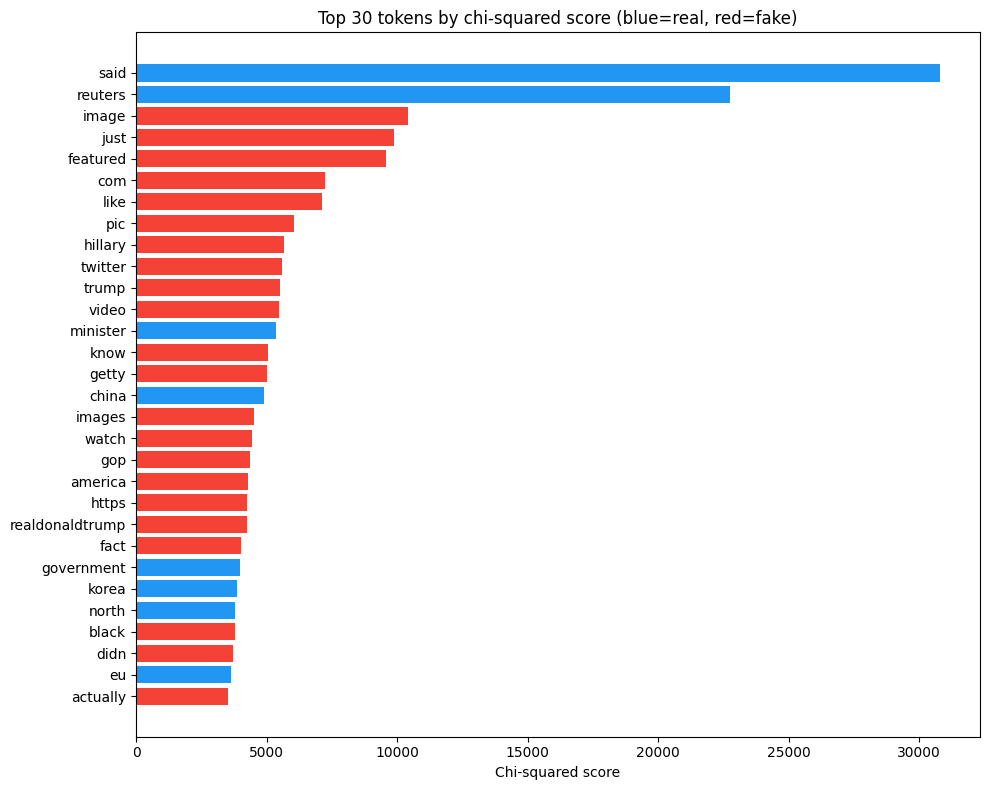

In [12]:
top_n = 30
top_chi2 = chi2_df.head(top_n).copy()
top_chi2["skew"] = top_chi2["ratio_real_fake"].apply(
    lambda r: "Skewed REAL" if r > 1 else "Skewed FAKE"
)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#2196F3" if s == "Skewed REAL" else "#F44336" for s in top_chi2["skew"]]
ax.barh(range(top_n), top_chi2["chi2_score"].values, color=colors)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_chi2["token"].values)
ax.invert_yaxis()
ax.set_xlabel("Chi-squared score")
ax.set_title("Top 30 tokens by chi-squared score (blue=real, red=fake)")
plt.tight_layout()
plt.show()

### Step 5: Classify top tokens — metadata artifact vs. content signal

For each high-scoring token, ask: **would a human use this to judge credibility based on content?**
- **Metadata artifact** → Remove in cleaning (source tags, formatting, datelines)
- **Content signal** → Keep (language style the model should learn)

In [13]:
# Show context: sample raw texts containing the top tokens so you can judge
# whether they are metadata or content

def show_token_context(token, df, n_samples=3):
    """Show raw text snippets containing the token from each class."""
    print(f"\n{'='*60}")
    print(f"Token: '{token}'")
    print(f"{'='*60}")
    for label, name in [(1, "REAL"), (0, "FAKE")]:
        subset = df[df["label"] == label]
        matches = subset[subset["text"].str.contains(token, case=False, na=False)]
        print(f"\n  [{name}] — {len(matches)} articles contain this token")
        for _, row in matches.head(n_samples).iterrows():
            idx = row["text"].lower().find(token.lower())
            start = max(0, idx - 60)
            end = min(len(row["text"]), idx + len(token) + 60)
            snippet = row["text"][start:end]
            print(f"    ...{snippet}...")

# Inspect the top 10 chi-squared tokens in context
for token in chi2_df["token"].head(10):
    show_token_context(token, raw_df)


Token: 'said'

  [REAL] — 19857 articles contain this token
    ...chairman of the small but influential House Freedom Caucus, said on the program. “Now, Democrats are saying that’s not enoug...
    ...arting on Monday as ordered by federal courts, the Pentagon said on Friday, after President Donald Trump’s administration de...
    ...n lawmakers to shut it down, a prominent Republican senator said on Sunday. Lindsey Graham, who serves on the Senate armed f...

  [FAKE] — 9883 articles contain this token
    ... nominee Hillary Clinton. Exactly how much Mr. Papadopoulos said that night at the Kensington Wine Rooms with the Australian...
    ...rowing tensions between Israelis and Palestinians,  Francis said.  On this festive day, let us ask the Lord for peace for Je...
    ... break on Wednesday, Donald Trump looked at the cameras and said,  We have essentially repealed Obamacare and we will come u...

Token: 'reuters'

  [REAL] — 21154 articles contain this token
    ...WASHINGTON (R

### Step 6: Bigram analysis

Single tokens may miss multi-word patterns like "(Reuters)" or "WASHINGTON (AP)". Repeat with bigrams.

In [14]:
bigram_vec = CountVectorizer(ngram_range=(2, 2), max_features=20_000, stop_words="english")
X_bi = bigram_vec.fit_transform(raw_df["text"])
bi_names = np.array(bigram_vec.get_feature_names_out())

bi_chi2_scores, bi_chi2_pvalues = chi2(X_bi, y)

bi_freq_real = np.asarray(X_bi[real_mask].sum(axis=0)).flatten()
bi_freq_fake = np.asarray(X_bi[fake_mask].sum(axis=0)).flatten()

bi_chi2_df = pd.DataFrame({
    "bigram": bi_names,
    "chi2_score": bi_chi2_scores,
    "freq_real": bi_freq_real,
    "freq_fake": bi_freq_fake,
    "ratio_real_fake": (bi_freq_real + 1) / (bi_freq_fake + 1),
}).sort_values("chi2_score", ascending=False)

print("=== Top 30 bigrams by chi-squared score ===")
bi_chi2_df.head(30)

=== Top 30 bigrams by chi-squared score ===


,bigram,chi2_score,freq_real,freq_fake,ratio_real_fake
5766,featured image,9334.378640,1,7691,0.000260
18715,twitter com,6221.014494,0,5124,0.000195
12312,pic twitter,5959.984417,0,4909,0.000204
19290,washington reuters,5458.988720,6638,3,1659.750000
6418,getty images,4883.083586,0,4022,0.000249
12820,president obama,3651.776001,178,3450,0.051869
12771,president donald,3153.565990,5865,701,8.356125
11087,north korea,2963.179451,5504,656,8.378995
17688,told reuters,2735.733514,3453,39,86.350000
12969,prime minister,2398.552846,4104,398,10.288221


### Step 7: Summary — document findings and cleaning decisions

After running the cells above, fill in this table based on what you observed.

| Token/Pattern | Chi2 rank | Freq ratio | Metadata or Content? | Action |
|---|---|---|---|---|
| reuters | 2 | 94.9 | Metadata (wire service tag) | Remove |
| said | 1 | 3.9 | Content | Leave |
| image | 3 | 0.04 | Content | Leave (good pattern for detecting fake news) | 
| video | 12 | 0.14

These findings directly justify each step in `clean_text()`.